In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

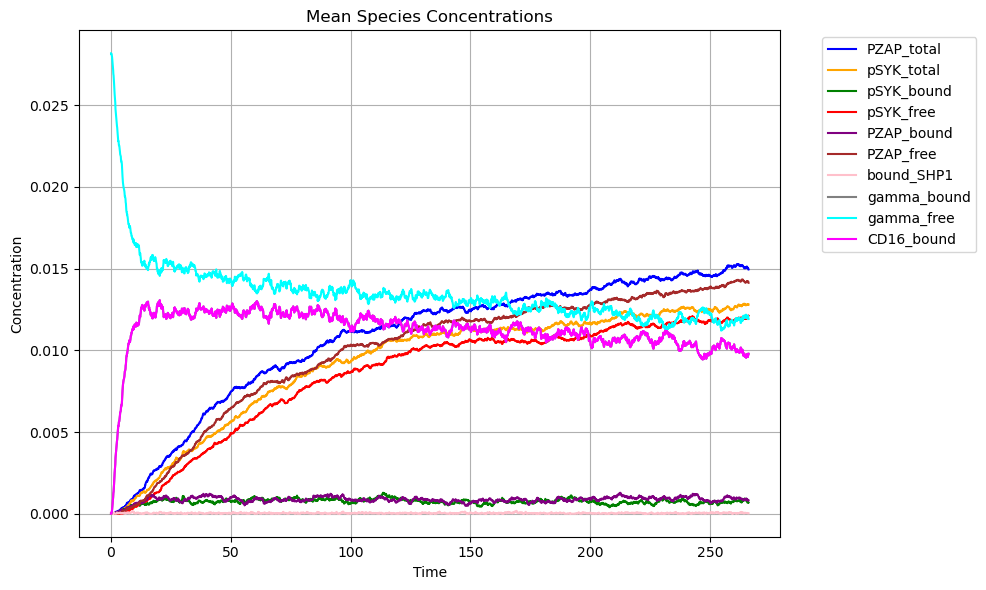

In [2]:
# Load and process data
directory = "gamma_runs/analysis/bng_output_"
data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]

# Define proper column labels
column_labels = ['PZAP_total', 'pSYK_total', 'pSYK_bound', 'pSYK_free', 
                'PZAP_bound', 'PZAP_free', 'bound_SHP1', 'gamma_bound', 
                'gamma_free', 'CD16_bound']

# Stack data and compute means
stacked = np.stack([df.values for df in data])
means = np.mean(stacked, axis=0)
time = data[0].iloc[:, 0]

# Plot all columns (skip time column)
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
for i, label in enumerate(column_labels):
    plt.plot(time, means[:, i+1]/(602.0*25.0), label=label, color=colors[i % len(colors)])

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Mean Species Concentrations")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



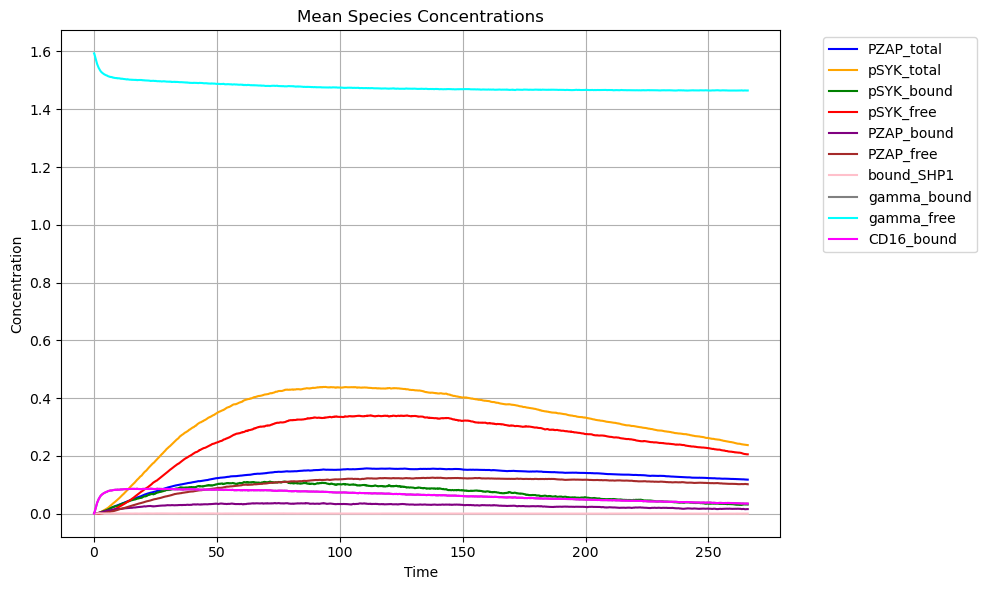

In [3]:
# Load and process data
directory = "zeta_runs/analysis/bng_output_"
data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]

# Define proper column labels
column_labels = ['PZAP_total', 'pSYK_total', 'pSYK_bound', 'pSYK_free', 
                'PZAP_bound', 'PZAP_free', 'bound_SHP1', 'gamma_bound', 
                'gamma_free', 'CD16_bound']

# Stack data and compute means
stacked = np.stack([df.values for df in data])
means = np.mean(stacked, axis=0)
time = data[0].iloc[:, 0]

# Plot all columns (skip time column)
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
for i, label in enumerate(column_labels):
    plt.plot(time, means[:, i+1]/(602.0*25), label=label, color=colors[i % len(colors)])

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Mean Species Concentrations")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


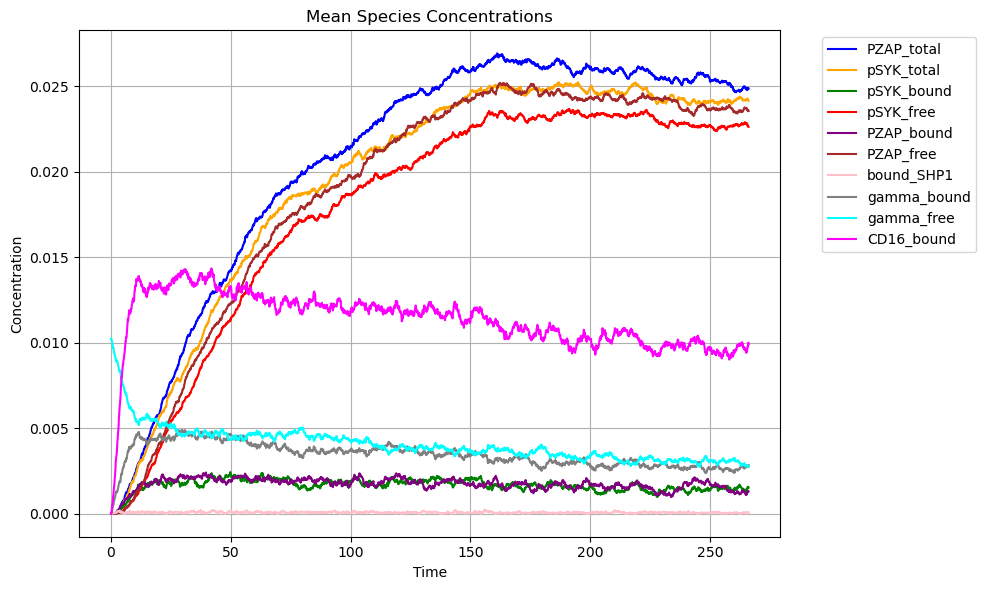

In [4]:
# Load and process data
directory = "mixed_runs/analysis/bng_output_"
data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]

# Define proper column labels
column_labels = ['PZAP_total', 'pSYK_total', 'pSYK_bound', 'pSYK_free', 
                'PZAP_bound', 'PZAP_free', 'bound_SHP1', 'gamma_bound', 
                'gamma_free', 'CD16_bound']

# Stack data and compute means
stacked = np.stack([df.values for df in data])
means = np.mean(stacked, axis=0)
time = data[0].iloc[:, 0]

# Plot all columns (skip time column)
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
for i, label in enumerate(column_labels):
    plt.plot(time, means[:, i+1]/(602.0*25), label=label, color=colors[i % len(colors)])

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Mean Species Concentrations")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


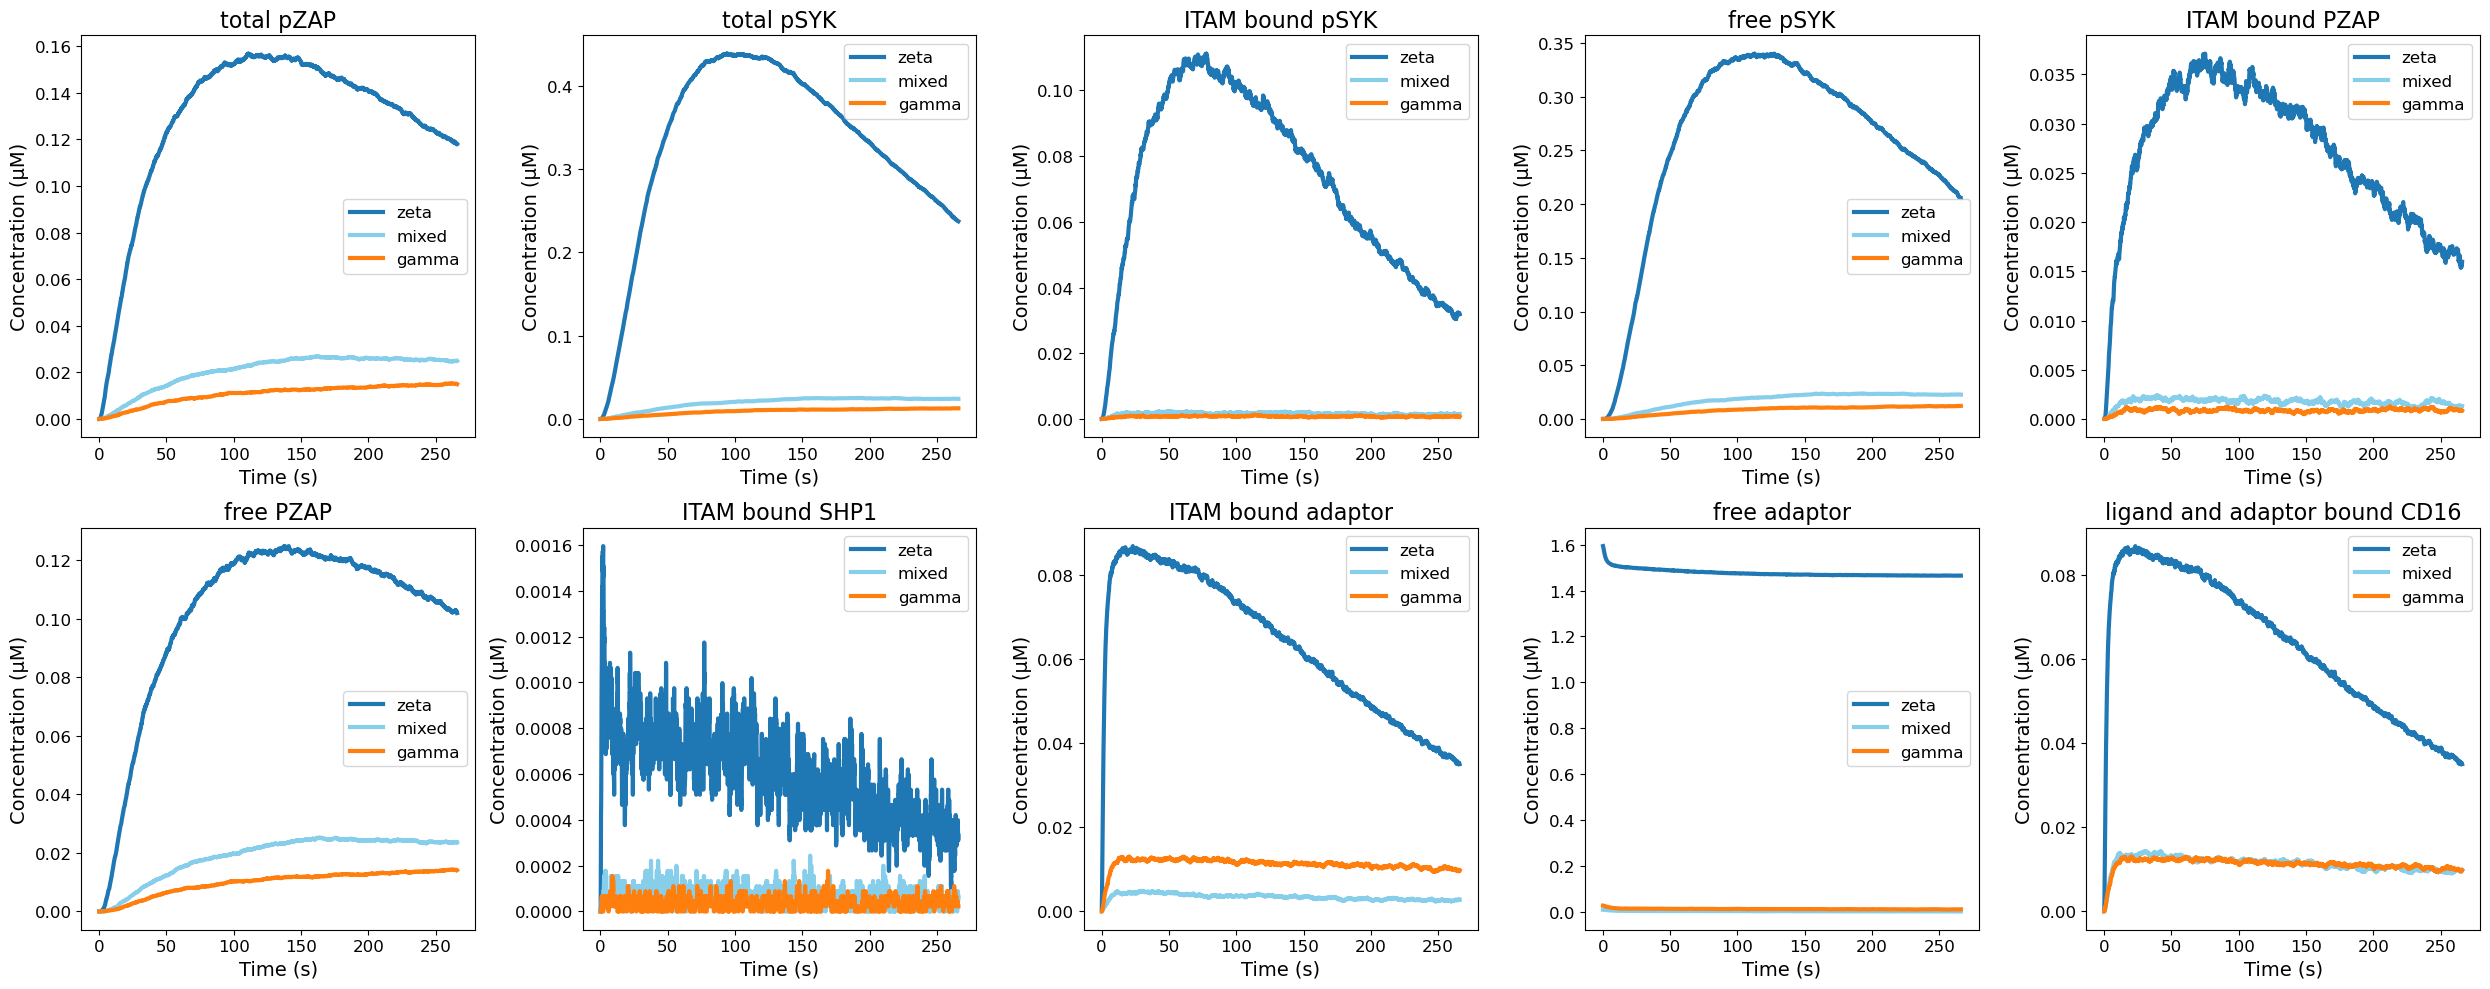

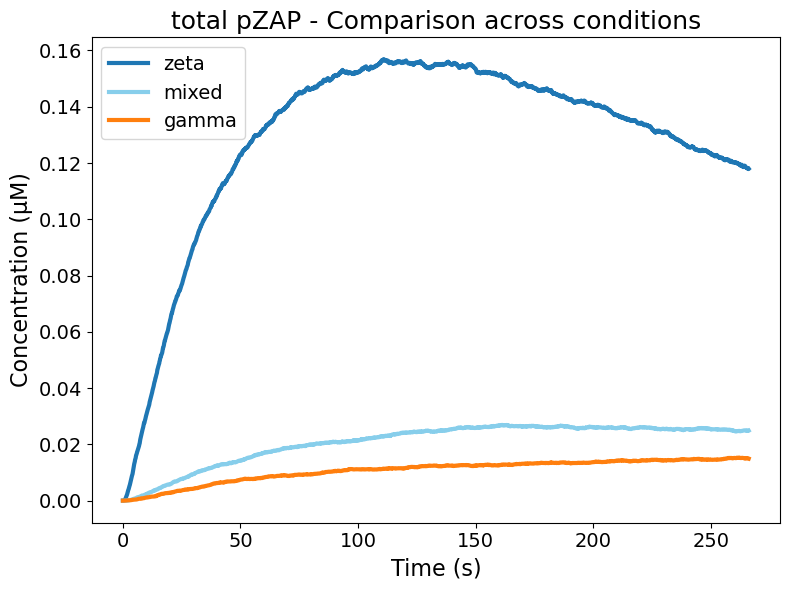

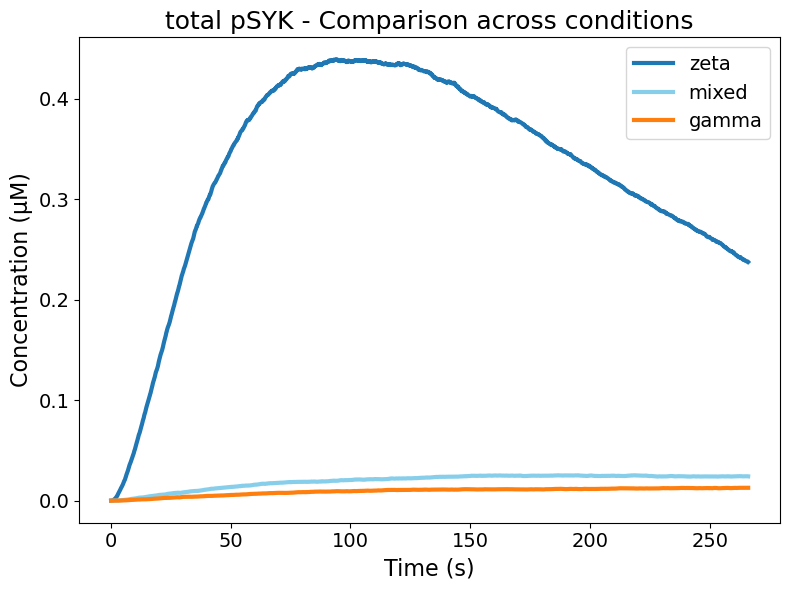

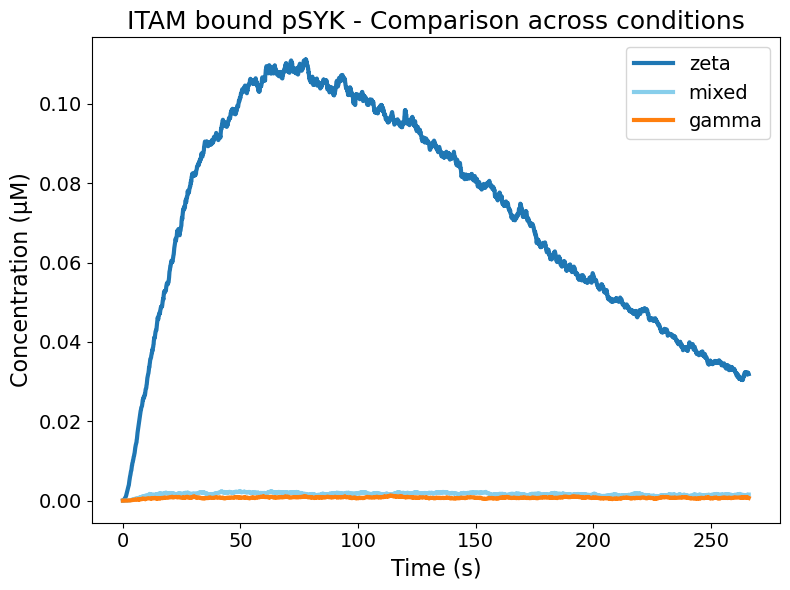

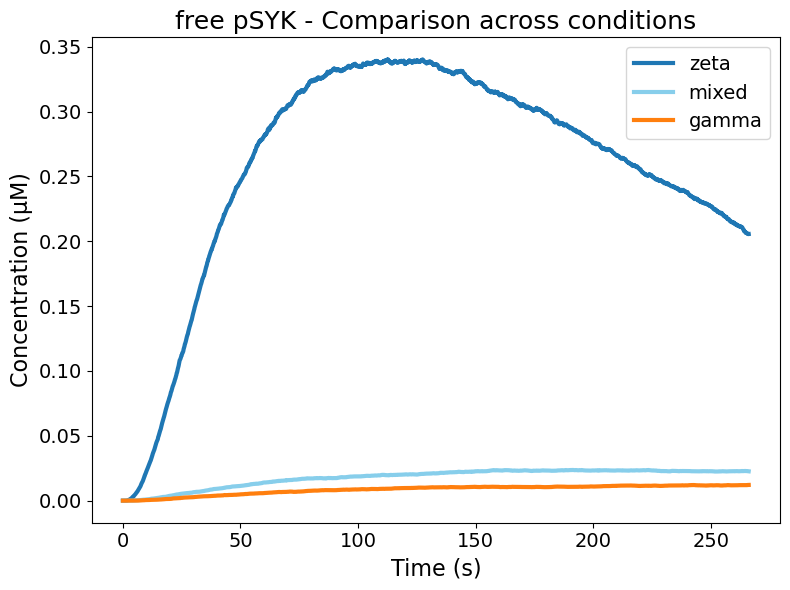

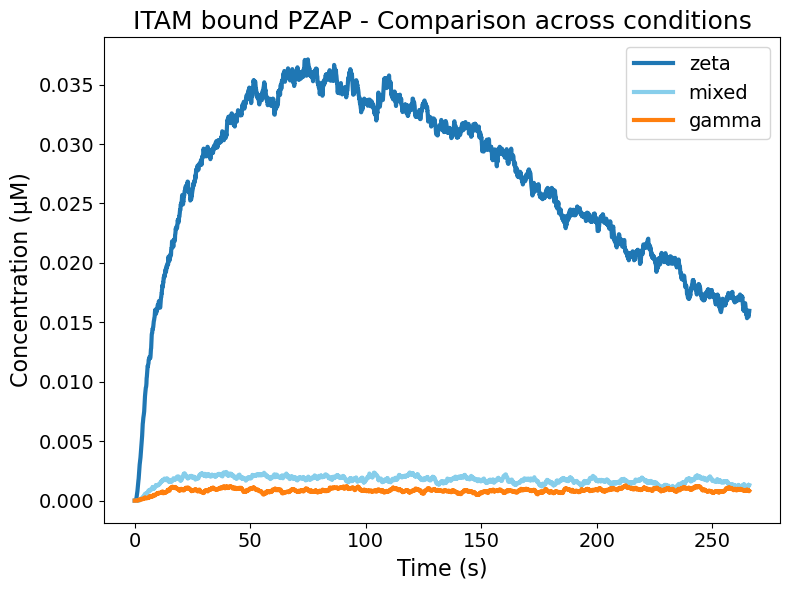

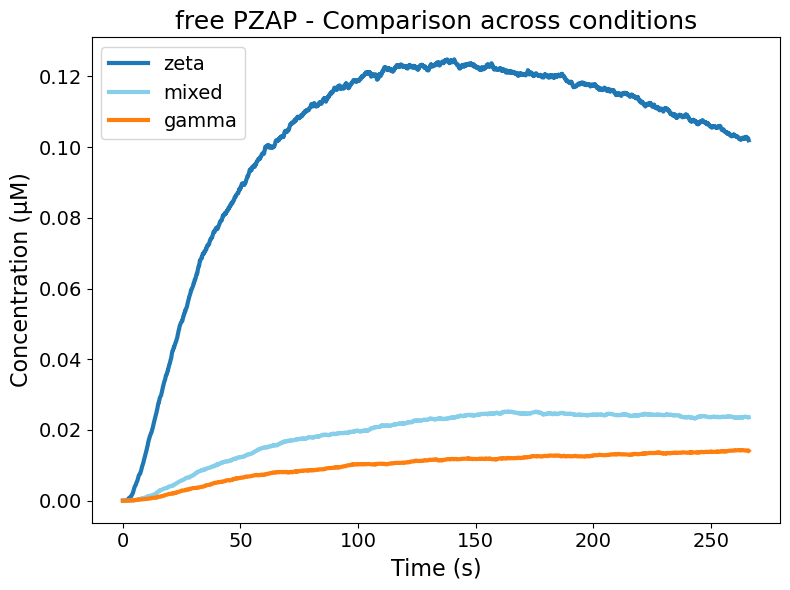

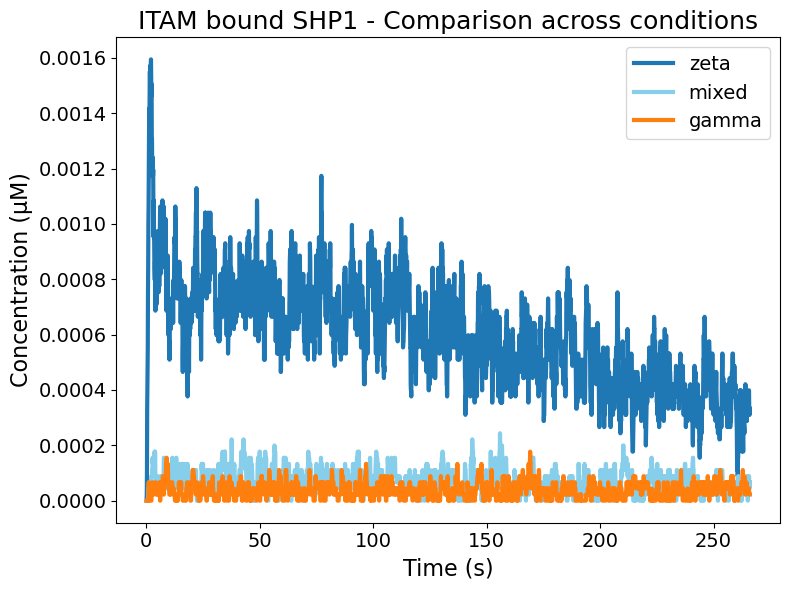

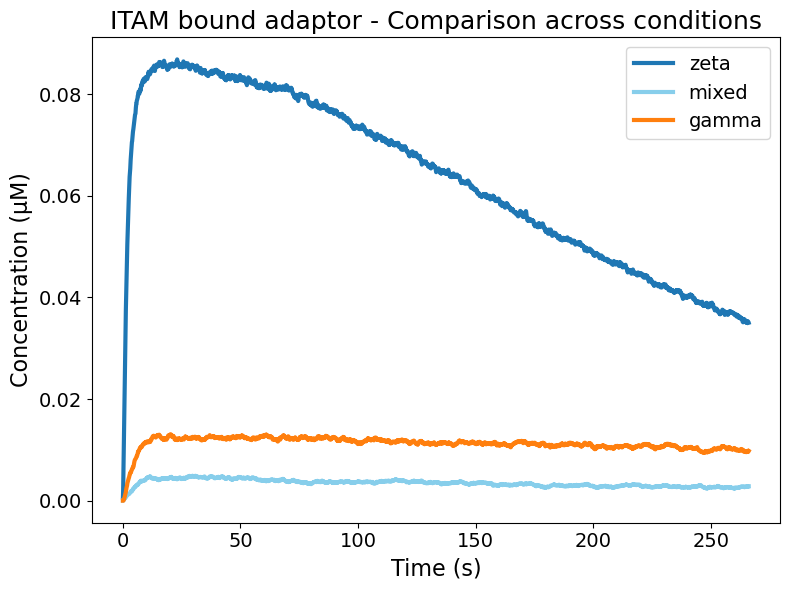

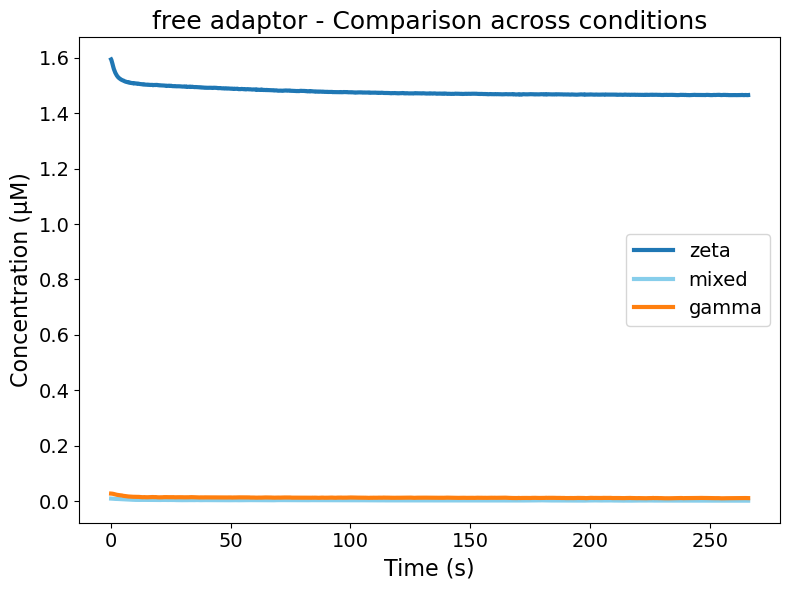

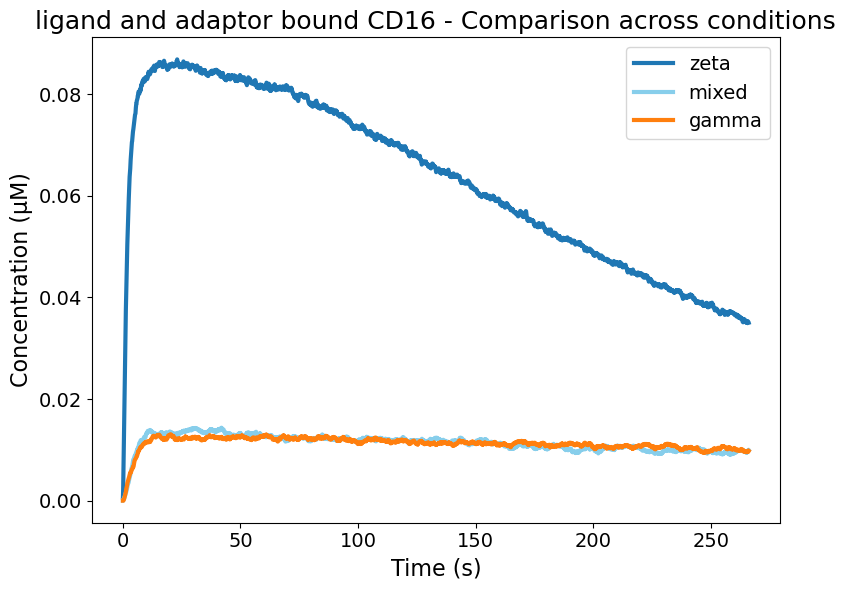

In [5]:
# Load data for all three conditions
directories = {
    'zeta': "zeta_runs/analysis/bng_output_",
    'mixed': "mixed_runs/analysis/bng_output_", 
    'gamma': "gamma_runs/analysis/bng_output_"
}

# Colors for each condition
colors = {'zeta': '#1f77b4', 'mixed': '#87ceeb', 'gamma': '#ff7f0e'}




# Column labels
column_labels = ['total pZAP', 'total pSYK', 'ITAM bound pSYK', 'free pSYK', 
                'ITAM bound PZAP', 'free PZAP', 'ITAM bound SHP1', 'ITAM bound adaptor', 
                'free adaptor', 'ligand and adaptor bound CD16']

# Load and process data for all conditions
all_data = {}
for condition, directory in directories.items():
    data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]
    stacked = np.stack([df.values for df in data])
    means = np.mean(stacked, axis=0)
    time = data[0].iloc[:, 0]
    all_data[condition] = {'time': time, 'means': means}

# Create subplot for each species
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, species in enumerate(column_labels):
    ax = axes[i]
    
    # Plot each condition for this species
    for condition in ['zeta', 'mixed', 'gamma']:
        time = all_data[condition]['time']
        concentration = all_data[condition]['means'][:, i+1] / (602.0 * 25.0)
        ax.plot(time, concentration, label=condition, color=colors[condition], linewidth=3)
    
    ax.set_xlabel('Time (s)', fontsize=14)
    ax.set_ylabel('Concentration (μM)', fontsize=14)
    ax.set_title(species, fontsize=16)
    ax.legend(fontsize=12)
    #ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

# Alternative: Individual plots for each species
for species_idx, species in enumerate(column_labels):
    plt.figure(figsize=(8, 6))
    
    for condition in ['zeta', 'mixed', 'gamma']:
        time = all_data[condition]['time']
        concentration = all_data[condition]['means'][:, species_idx+1] / (602.0 * 25.0)
        plt.plot(time, concentration, label=condition, color=colors[condition], linewidth=3)
    
    plt.xlabel('Time (s)', fontsize=16)
    plt.ylabel('Concentration (μM)', fontsize=16)
    plt.title(f'{species} - Comparison across conditions', fontsize=18)
    plt.legend(fontsize=14)
    #plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.show()